#**Flood Susceptibility Data Cleaning**

## **About the data:**


* F_NF: This is likely a binary variable that indicates whether a location is
prone to flooding or not. F_NF could stand for Flood/No Flood.

* Aspect: This is the direction in which a slope faces. The aspect can affect the amount of solar radiation a slope receives, which can influence evaporation and snowmelt rates.

* DEM: Digital Elevation Model. It represents the elevation of a location relative to sea level. Elevation can affect the likelihood and severity of flooding, as low-lying areas are more susceptible to flooding than higher elevations.

* Distance from river: This feature represents the distance between a location and a river. Locations closer to a river may be more prone to flooding, especially during periods of heavy rainfall or snowmelt.

* Flow accumulation: This is a measure of the total volume of water that flows through a given location. Higher flow accumulation can indicate areas with high runoff potential, which can increase the likelihood of flooding.

* Land use: This is the type of land cover at a location. Land use can affect the amount and rate of water infiltration into the soil, which can influence runoff rates and flooding potential.

* Lithology: This is the type of rock or soil at a location. Lithology can affect the permeability of the ground and the amount of water that can be stored within it.

* Plan curvature: This is a measure of how a slope curves in a two-dimensional plane. Plan curvature can influence the direction and speed of water flow over the surface.

* Profile curvature: This is a measure of how a slope curves in a three-dimensional space. Profile curvature can influence the amount and speed of water flow over the surface.

* Rainfall: This is the amount of precipitation that falls at a location. Heavy rainfall can increase the likelihood and severity of flooding.

* Slope: This is the steepness of a slope. Steeper slopes can lead to higher runoff rates and increased flood potential.

* Soil: This is the type of soil at a location. Soil type can affect the infiltration rate and water-holding capacity of the ground, which can influence the potential for flooding.

* SPI: Standardized Precipitation Index (SPI) is a measure of precipitation deficits or surpluses over a specific time period relative to the long-term average. SPI values are standardized to a normal distribution, making it easier to compare different regions and time periods. SPI values can indicate the severity and duration of drought or excess rainfall events, which can contribute to flooding.

* TPI: Temperature Precipitation Index (TPI) is a measure of the combined effects of temperature and precipitation on water availability. TPI values are calculated by combining SPI and temperature data. This index considers both precipitation and temperature conditions to determine the water balance, which affects flood occurrence.

* TRI: Topographic Wetness Index (TRI) is a measure of landscape topography and its ability to retain water. It is calculated using digital elevation models and other data such as soil texture, vegetation, and land use. TRI values indicate areas with a high potential for surface runoff and saturation, which can contribute to flooding.

* TWI: Terrain Wetness Index (TWI) is a measure of soil moisture content and its effect on the potential for flooding. TWI values are calculated using topographic and soil data, and they indicate areas with a high potential for saturation and surface runoff. TWI is especially useful in predicting flash floods, where heavy precipitation falls on already saturated soil.

## Step 1: Import Libraries + Load the Data

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

In [ ]:
drive.mount('/content/drive', force_remount=False)

Mounted at /content/drive


In [ ]:
FS_Dataset = pd.read_excel('/content/drive/MyDrive/FS_Dataset/F_NF_L.xlsx')

In [ ]:
df = FS_Dataset.copy()

In [ ]:
df.head()

,F_NF,aspect,DEM,Distance_ from_river,Flow accumulation,Land use,lithology,plan_curvature,Profile curvature,Rainfall,Slope,Soil,SPI,TPI,TRI,TWI
0,0,152.406998,190.559006,1368.959961,1,55,2,0.067631,0.211239,48.571201,16.280100,3,7.80579,41.069000,0.413917,5.28709
1,0,354.906006,151.307999,1654.119995,0,55,5,0.609126,0.246157,48.051300,5.885500,3,0.00000,13.969300,0.412784,5.63530
2,0,124.499000,62.149200,2633.239990,3,32,2,-0.109510,0.134615,49.509499,5.921960,3,11.52480,2.549050,0.287488,7.01537
3,0,356.993012,203.268997,798.232971,1,55,5,0.289751,-0.549690,46.925899,15.132800,3,7.42482,23.202999,0.350754,5.36396
4,0,233.602997,8.951080,798.232971,0,16,3,0.006961,-0.035492,53.556301,0.697421,3,0.00000,0.017024,0.131066,7.77163


## Step 2: Clean Column Names

In [ ]:
df.columns

Index(['F_NF', 'aspect', 'DEM', 'Distance_ from_river', 'Flow accumulation',
       'Land use', 'lithology', 'plan_curvature', 'Profile curvature',
       'Rainfall', 'Slope', 'Soil', 'SPI', 'TPI', 'TRI', 'TWI'],
      dtype='object')

In [ ]:
# Normalize all column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

df.columns

Index(['f_nf', 'aspect', 'dem', 'distance_from_river', 'flow_accumulation',
       'land_use', 'lithology', 'plan_curvature', 'profile_curvature',
       'rainfall', 'slope', 'soil', 'spi', 'tpi', 'tri', 'twi'],
      dtype='object')

##  Step 3: Explore Summary Statistics to Identify Anomalies

In [ ]:
# Quick summary of numeric columns
df.describe()

,f_nf,aspect,dem,distance_from_river,flow_accumulation,land_use,lithology,plan_curvature,profile_curvature,rainfall,slope,soil,spi,tpi,tri,twi
count,282.000000,282.000000,282.000000,282.000000,282.000000,282.000000,282.000000,282.000000,282.000000,282.000000,282.000000,282.000000,282.000000,282.000000,282.000000,282.000000
mean,0.500000,113.235343,12.188307,826.464402,256.500000,-20.241135,-67.460993,-70.884255,-70.924940,-21.064985,-65.596154,-68.017730,296.942903,-68.283620,0.314280,-63.134006
std,0.500889,863.101254,851.916595,1128.864390,3411.526911,845.084139,840.861103,840.570669,840.567221,844.790981,841.042827,840.813364,3546.818889,840.882691,0.129958,841.230747
min,0.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,0.023635,-9999.000000
25%,0.000000,81.990776,16.315875,387.200012,0.000000,32.000000,3.000000,-0.114071,-0.142188,48.844173,0.843059,3.000000,0.000000,-2.896905,0.216479,5.962155
50%,0.500000,193.790497,44.445900,786.315979,1.000000,55.000000,3.000000,0.006001,-0.002951,50.355551,2.608680,3.000000,1.689880,-0.135913,0.316001,6.953315
75%,1.000000,281.520744,139.842998,1355.199951,5.000000,68.000000,5.000000,0.172004,0.130887,51.555625,6.969310,3.000000,10.532468,4.199828,0.409819,9.192728
max,1.000000,359.299011,377.085999,3296.889893,38581.000000,68.000000,5.000000,0.846791,1.717200,54.413399,31.481701,3.000000,48903.398438,59.337200,0.764255,18.921200


 Here I noticed very low (- 9999) values in some features which need more invistigation.


In [ ]:
# Where did -9999 appear?
(df == -9999).sum()  # This reveals how many columns had it and how many times

,0
f_nf,0
aspect,2
dem,2
distance_from_river,2
flow_accumulation,2
land_use,2
lithology,2
plan_curvature,2
profile_curvature,2
rainfall,2


In [ ]:
# View rows with any -9999
df[df.isin([-9999]).any(axis=1)]

,f_nf,aspect,dem,distance_from_river,flow_accumulation,land_use,lithology,plan_curvature,profile_curvature,rainfall,slope,soil,spi,tpi,tri,twi
183,1,-9999.0,-9999.0,-9999.0,-9999,-9999,-9999,-9999.0,-9999.0,-9999.0,-9999.0,-9999,-9999.0,-9999.0,0.369833,-9999.0
230,1,-9999.0,-9999.0,-9999.0,-9999,-9999,-9999,-9999.0,-9999.0,-9999.0,-9999.0,-9999,-9999.0,-9999.0,0.199599,-9999.0



After cleaning the column names, I reviewed the summary statistics to understand the distribution of the data. I noticed an unusual minimum value of `-9999` in several numerical columns, which is not physically plausible in this context (e.g., negative DEM or rainfall values).

This observation led me to further investigate and confirm that these `-9999` values represent NoData cells extracted from GIS rasters, as documented in ArcGIS tools [source](https://pro.arcgis.com/en/pro-app/latest/tool-reference/spatial-analyst/extract-values-to-points.htm).

I then checked how many columns and rows contain `-9999`, and found exactly 2 rows affected.


### Remove Invalid Rows (NoData = -9999)

Since these rows do not contain reliable measurements for flood conditioning factors, I will remove them from the dataset to avoid introducing noise or errors into later stages (EDA, modeling, or synthetic data generation).

This action aligns with best practices recommended in GIS-based flood modeling literature (e.g., Tehrany et al., 2014; ArcGIS Spatial Analyst documentation).

In [ ]:
df.shape

(282, 16)

In [ ]:
# Remove rows that contain -9999 in any column
df = df[~df.isin([-9999]).any(axis=1)].copy()

# Confirm new shape
df.shape

(280, 16)

## Step 4: Check Columns Types

In [ ]:
df.dtypes

,0
f_nf,int64
aspect,float64
dem,float64
distance_from_river,float64
flow_accumulation,int64
land_use,int64
lithology,int64
plan_curvature,float64
profile_curvature,float64
rainfall,float64


### Convert Categorical Columns


For more meaningful analysis and efficient storage, we convert columns like land use, lithology, soil type, and F_NF to categorical.

In [ ]:
categorical_cols = ['f_nf', 'land_use', 'lithology', 'soil']
for col in categorical_cols:
    df[col] = df[col].astype('category')

df.dtypes


,0
f_nf,category
aspect,float64
dem,float64
distance_from_river,float64
flow_accumulation,int64
land_use,category
lithology,category
plan_curvature,float64
profile_curvature,float64
rainfall,float64


## Step 5: Check for Duplicates

To check if any rows are exact duplicates and remove them if needed.


In [ ]:
df.duplicated().sum()  # Number of duplicate rows

np.int64(0)

## Step 6: Outlier Detection and Analysis

In environmental datasets, extreme values can either represent real flood-prone conditions or errors (e.g., from NoData cells). Instead of automatically removing outliers, we investigate them using boxplots and descriptive statistics.

This is in line with best practices in flood susceptibility studies, such as Tehrany et al. (2014), which recommend retaining extreme values when they represent meaningful terrain or hydrologic phenomena.


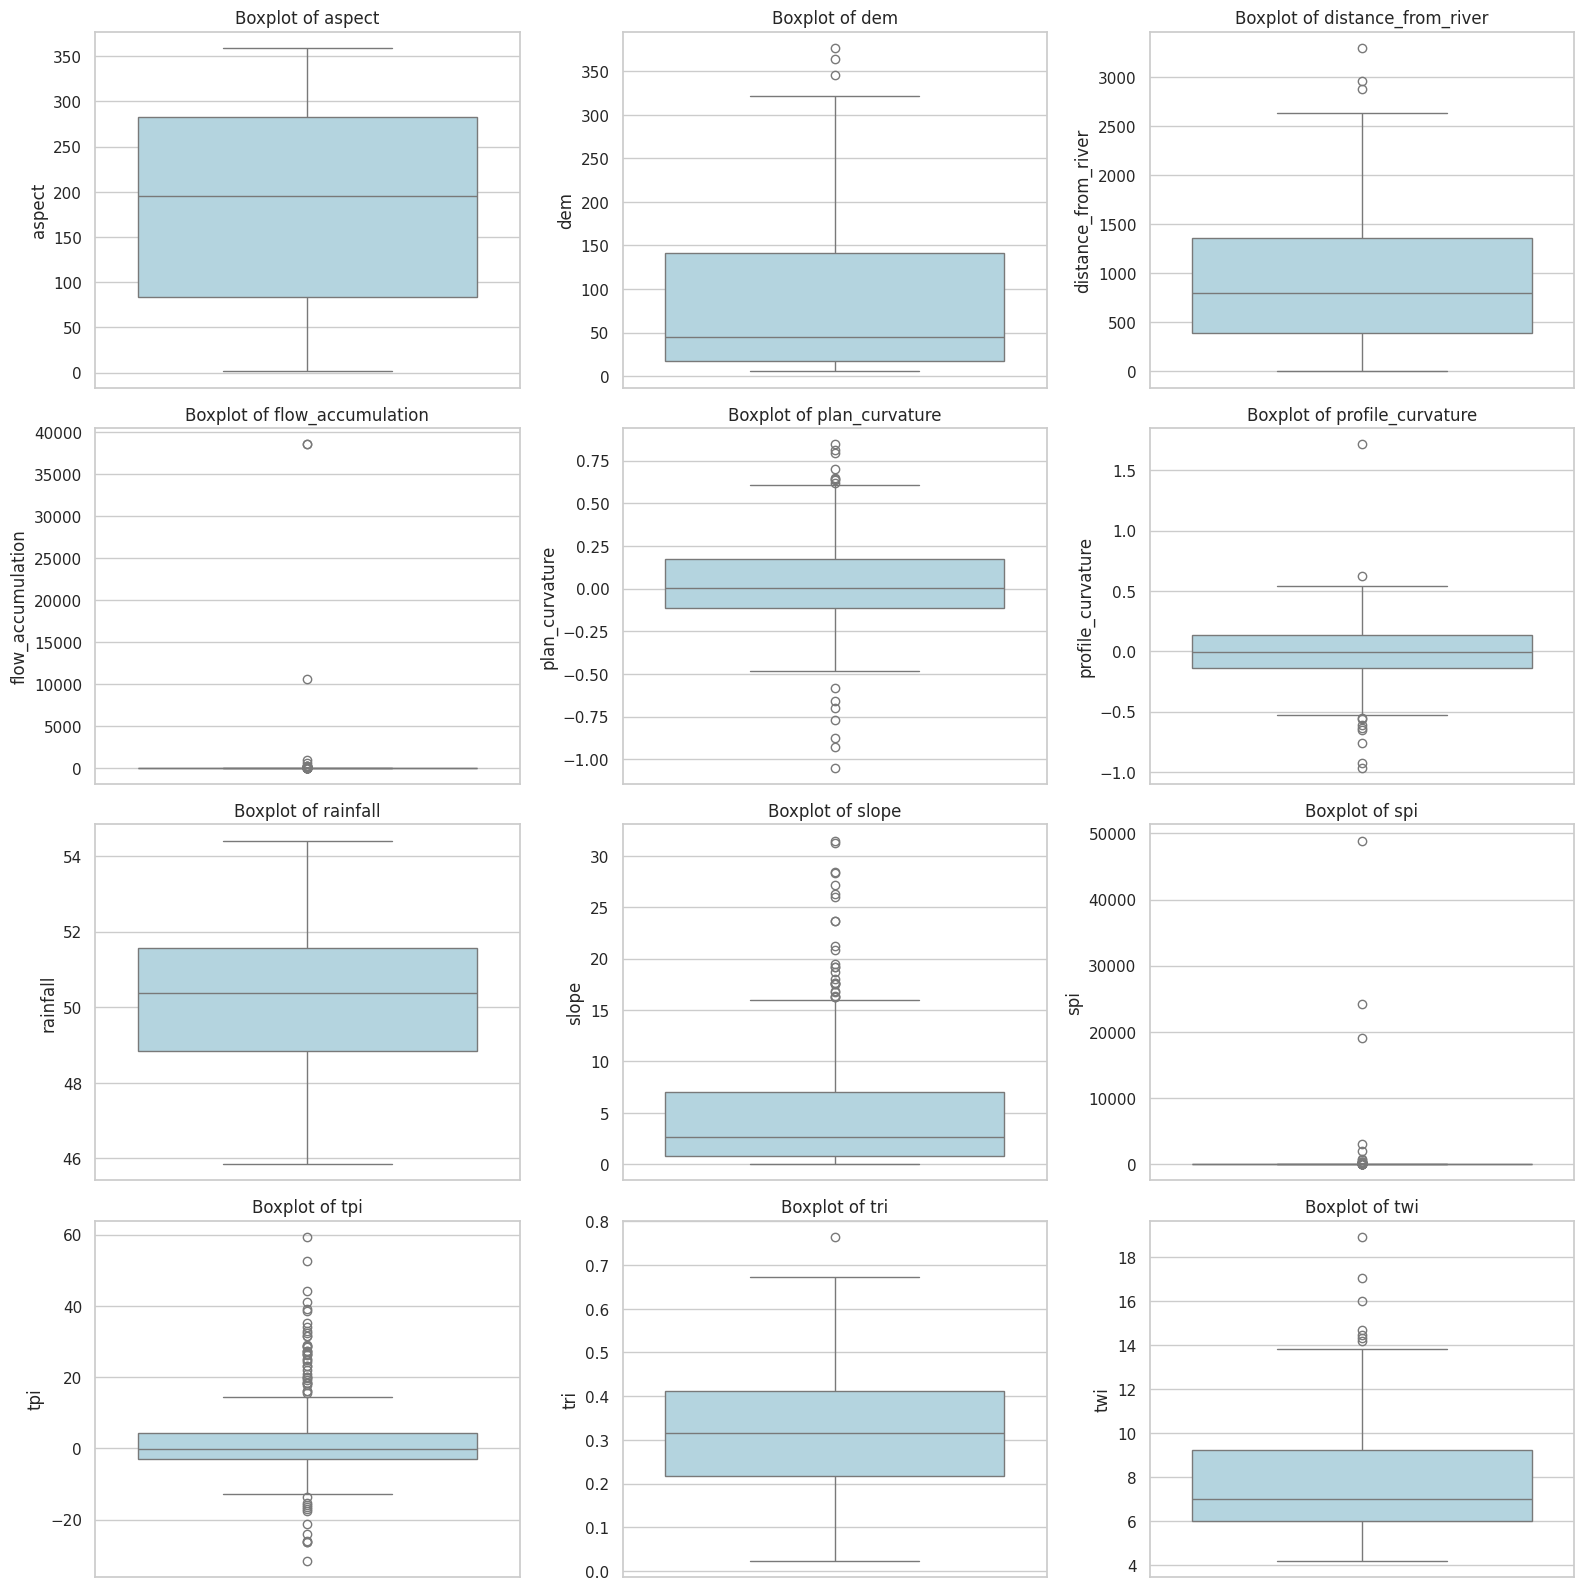

In [ ]:
# Set visual style
sns.set(style="whitegrid")

# Select only numerical features
numerical_features = df.select_dtypes(include=['float64', 'int64']).columns

# Plot boxplots for each feature
plt.figure(figsize=(16, 20))
for i, column in enumerate(numerical_features, 1):
    plt.subplot(5, 3, i)
    sns.boxplot(y=df[column], color='lightblue')
    plt.title(f"Boxplot of {column}")
    plt.tight_layout()
plt.show()

Boxplots were used to visualize outliers across all continuous flood conditioning factors. Outliers appear as individual points beyond the whiskers, which represent 1.5 × IQR from the lower and upper quartiles.

In this dataset, multiple features show the presence of outliers, such as:

- **Flow accumulation**: A few extremely high values, likely natural in catchment modeling.
- **SPI, TPI, TWI**: Some very large or small values, potentially indicating local terrain variability.
- **Slope**: Steep areas up to ~30°, which are plausible in mountainous or rugged terrain.

These outliers were **not removed** because:
- They represent **real environmental extremes**, not data entry errors.
- Previous studies (Tehrany et al., 2014; Youssef et al., 2016) recommend keeping such values when they are physically valid.

Instead, these values will be retained for modeling and properly handled using models that are robust to outliers (e.g., decision trees, ensemble methods, deep learning).


## Step 7: Save the Cleaned Dataset

We export the cleaned data to a CSV file for later use in analysis or synthetic data generation.


In [ ]:
df.to_csv("Cleaned_Flood_Data.csv", index=False)